In [1]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold

from data_preprocessing.get_stnthetic_data import *

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)  # ✅ Set your global seed here

## Load dataset

#### Synthetic data

In [2]:
file_path = "/Users/sonali/Documents/CMU/Spring 2025/BME AI/Multimodal-DL-and-Explainable-AI-for-Optimizing-NSCLC-Immunotherapy-mlpv3/data/rfe_50.csv"  #(n, file, train_set_ratio, target, k):
target_val = 'ps'
train_set_bs, test_set_bs, train_set_ps, test_set_ps, train_set_po, test_set_po = get_synthetic_data(n= 600, file=file_path ,train_set_ratio=0.7, k=3)

# Change the input here
def input(train):
    X = train.iloc[:, :-1].values
    print(X.shape)
    
    # Standardize the features
    #scaler = StandardScaler()
    #X_scaled = scaler.fit_transform(X)
    
    target_col = train.columns[-1]
    print(target_col)
    y = train[target_col].values
    print("Label distribution:", Counter(y))

    features = train.columns[:-1]
    return X, y, features

X, y, features = input(train_set_ps)

(600, 50)
Potential status
Label distribution: Counter({0.0: 300, 1.0: 300})


### Define MLP

In [3]:
# Define MLP Model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_dims=[16, 8, 4], dropout=0.3):
        super(MLP, self).__init__()
        layers = []
        in_dim = input_size
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.model(x))

### Training

In [4]:
def cross_validate_models(X_scaled, y, model_configs, num_epochs=100, batch_size=64):
    results = []

    for config in model_configs:
        print(f"\n🔍 Testing model config: {config}")

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        train_f1_scores, val_f1_scores = [], []
        train_acc_scores, val_acc_scores = [], []


        for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
            X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
            y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
            y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

            train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)

            model = MLP(input_size=X_scaled.shape[1], hidden_dims=config["hidden_dims"], dropout=config["dropout"])
            criterion = nn.BCELoss()
            optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-2)
            #scheduler = StepLR(optimizer, step_size=50, gamma=0.9)

            all_train_preds, all_train_labels = [], []
            for epoch in range(num_epochs):
                model.train()
                for inputs, labels in train_loader:
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    preds = (outputs > 0.5).float()
                    all_train_preds.extend(preds.cpu().numpy())
                    all_train_labels.extend(labels.cpu().numpy())
                    
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()
                    
                #scheduler.step()
            
            train_f1 = f1_score(all_train_labels, all_train_preds)
            train_acc = accuracy_score(all_train_labels, all_train_preds)
            train_f1_scores.append(train_f1)
            train_acc_scores.append(train_acc)

            # Evaluation
            model.eval()
            all_val_preds, all_val_labels = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    outputs = model(inputs)
                    preds = (outputs > 0.5).float()
                    all_val_preds.extend(preds.cpu().numpy())
                    all_val_labels.extend(labels.cpu().numpy())

            
            val_f1 = f1_score(all_val_labels, all_val_preds)
            val_acc = accuracy_score(all_val_labels, all_val_preds)
            val_f1_scores.append(val_f1)
            val_acc_scores.append(val_acc)
            
            print(f"Fold {fold+1}: Train F1={train_f1:.4f}, Val F1={val_f1:.4f}")

        config['avg_train_f1'] = np.mean(train_f1_scores)
        config['avg_val_f1'] = np.mean(val_f1_scores)
        config['avg_train_acc'] = np.mean(train_acc_scores)
        config['avg_val_acc'] = np.mean(val_acc_scores)
        
        print(f"✅ Config {config['hidden_dims']} → Train acc: {config['avg_train_acc']:.4f}, Val acc: {config['avg_val_acc']:.4f}")
        print(f"✅ Config {config['hidden_dims']} → Train F1: {config['avg_train_f1']:.4f}, Val F1: {config['avg_val_f1']:.4f}")

        results.append(config)

    return sorted(results, key=lambda x: x['avg_val_f1'], reverse=True)


In [5]:
def train_final_model(X_scaled, y, hidden_dims, dropout=0.3, num_epochs=100, batch_size=64, save_path="final_model.pt"):
    print("\n🚀 Training final model with best config...")
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = MLP(input_size=X_scaled.shape[1], hidden_dims=hidden_dims, dropout=dropout)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-2)
    #scheduler = StepLR(optimizer, step_size=50, gamma=0.9)

    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        #scheduler.step()
    torch.save(model.state_dict(), save_path)
    print(f"✅ Final model saved to {save_path}")
    return model, X_tensor


In [6]:
def evaluate_on_test(model, X_test, y_test):
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    with torch.no_grad():
        outputs = model(X_test_tensor)
        preds = (outputs > 0.5).float().cpu().numpy()
        labels = y_test_tensor.cpu().numpy()

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    print(f"\n🧪 Final Evaluation on Test Set:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    return X_test_tensor

In [7]:
model_configs = [
    {"hidden_dims": [16, 8, 4], "dropout": 0.3},
    {"hidden_dims": [32, 16], "dropout": 0.3},
    {"hidden_dims": [64, 32], "dropout": 0.2},
    {"hidden_dims": [16, 8], "dropout": 0.3}
]

# Step 1: Select the best model
sorted_configs = cross_validate_models(X, y, model_configs)


🔍 Testing model config: {'hidden_dims': [16, 8, 4], 'dropout': 0.3}
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Fold 1: Train F1=0.8855, Val F1=1.0000
Fold 2: Train F1=0.8779, Val F1=1.0000
Fold 3: Train F1=0.9007, Val F1=1.0000
Fold 4: Train F1=0.8951, Val F1=1.0000
Fold 5: Train F1=0.8683, Val F1=1.0000
✅ Config [16, 8, 4] → Train acc: 0.8889, Val acc: 1.0000
✅ Config [16, 8, 4] → Train F1: 0.8855, Val F1: 1.0000

🔍 Testing model config: {'hidden_dims': [32, 16], 'dropout': 0.3}
Fold 1: Train F1=0.9585, Val F1=1.0000
Fold 2: Train F1=0.9396, Val F1=0.9917
Fold 3: Train F1=0.9452, Val F1=1.0000
Fold 4: Train F1=0.9508, Val F1=1.0000
Fold 5: Train F1=0.9547, Val F1=1.0000
✅ Config [32, 16] → Train acc: 0.9502, Val acc: 0.9983
✅ Config [32, 16] → Train F1: 0.9498, Val F1: 0.9983

🔍 T

In [8]:
best_config = sorted_configs[0]
print(f"best config: {best_config}")

# Step 2: retrain best model on full training set
final_model, X_train_tensor = train_final_model(X, y, hidden_dims=best_config['hidden_dims'], dropout=best_config['dropout'])

# Step 3: test set
X_test, y_test, features= input(test_set_ps)
X_test_tensor = evaluate_on_test(final_model, X_test, y_test)
# evaluate_on_test(final_model, X_test, y_test)

best config: {'hidden_dims': [16, 8, 4], 'dropout': 0.3, 'avg_train_f1': 0.8854866821400735, 'avg_val_f1': 1.0, 'avg_train_acc': 0.8888666666666667, 'avg_val_acc': 1.0}

🚀 Training final model with best config...
✅ Final model saved to final_model.pt
(22, 50)
Potential status
Label distribution: Counter({0.0: 18, 1.0: 4})

🧪 Final Evaluation on Test Set:
Accuracy: 0.8636, Precision: 0.6667, Recall: 0.5000, F1: 0.5714


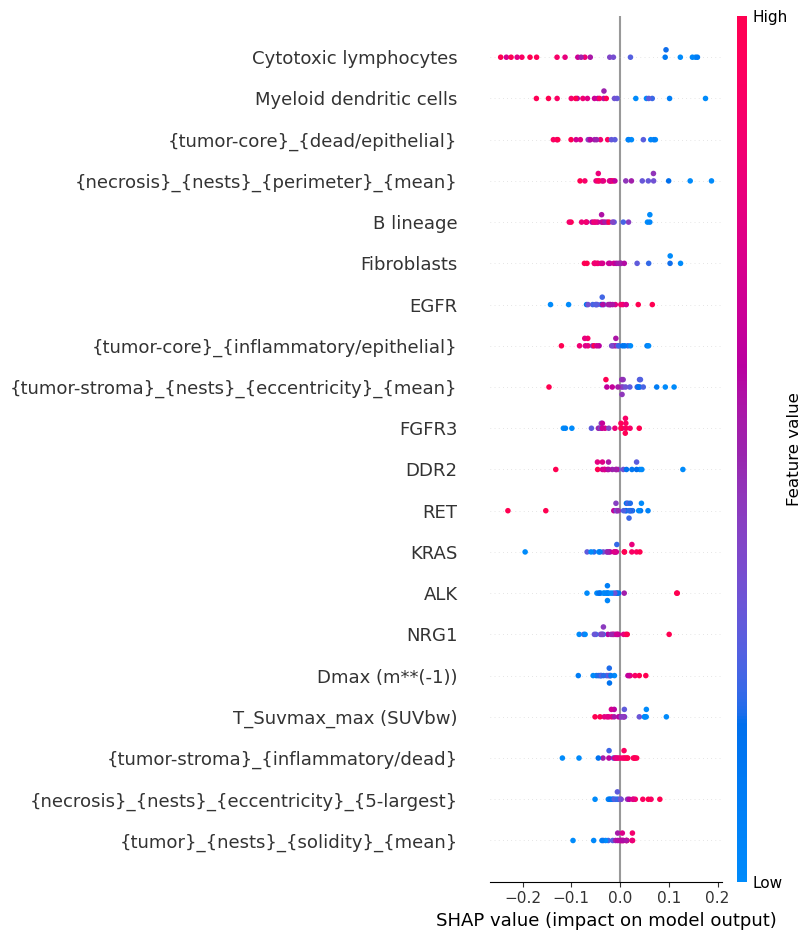

,B lineage,CD8 T cells,Cytotoxic lymphocytes,Endothelial cells,Fibroblasts,Monocytic lineage,Myeloid dendritic cells,NK cells,T cells,KRAS,...,{tumor}_{nests}_{solidity}_{mean},{tumor}_{nests}_{perimeter/area}_{5-largest},{tumor}_{major-axis-length}_{global},{tumor-stroma}_{nests}_{eccentricity}_{mean},{necrosis}_{nests}_{perimeter}_{mean},{necrosis}_{nests}_{perimeter}_{1-largest},{necrosis}_{nests}_{eccentricity}_{5-largest},{necrosis}_{nests}_{solidity}_{20-largest},{inflammatory}_{nests}_{eccentricity}_{1-largest},{inflammatory}_{nests}_{eccentricity}_{20-largest}
0,-0.031084,-0.010266,-0.061116,-0.006360,-0.052419,0.012474,-0.045710,0.006401,0.003528,0.008718,...,0.006757,0.001160,0.000009,0.003504,0.011749,0.011416,-0.016190,-0.016964,-0.012499,0.001867
1,0.006608,-0.034070,0.123671,0.028048,0.124099,-0.032074,0.032290,-0.032997,-0.011649,-0.194768,...,-0.096530,-0.007922,-0.000666,0.036341,-0.034024,0.007066,0.046686,-0.021222,0.000913,0.002286
2,-0.034769,0.002754,-0.129344,0.008876,0.034978,0.005285,-0.033528,0.015243,0.002515,-0.027301,...,-0.029633,0.003221,-0.000977,-0.016028,-0.045370,0.009046,0.026224,-0.022899,0.003587,-0.002805
3,0.061040,-0.016182,0.094276,0.003661,-0.067829,0.000742,0.066047,-0.016881,-0.009481,0.033848,...,0.005486,-0.019912,0.002081,0.040788,0.099696,-0.032339,-0.005695,0.017693,-0.000793,-0.000434
4,-0.037864,-0.023112,0.092553,-0.005701,-0.046874,-0.003206,-0.052488,-0.014612,0.000379,0.040648,...,-0.009174,-0.001579,-0.000417,0.006328,-0.044675,-0.010856,-0.019935,0.000832,-0.000020,0.000022
5,-0.045809,-0.007467,-0.086696,-0.025103,-0.020674,-0.002110,-0.076305,0.002976,0.003701,-0.009269,...,0.001884,0.001834,-0.000097,0.006331,-0.021684,-0.011773,-0.014184,0.008496,-0.003038,0.001498
6,-0.068514,0.010107,0.154841,0.014302,-0.045011,0.010661,-0.011518,-0.025421,-0.003038,-0.053587,...,-0.037159,-0.016873,0.000402,0.003069,-0.072284,0.030557,0.057988,-0.042639,0.001853,0.004286
7,-0.078873,-0.007801,-0.244954,0.001601,0.008717,0.019002,-0.146884,0.037569,0.018498,-0.020373,...,0.003603,0.007936,-0.000859,0.020064,0.045583,-0.054354,0.018973,-0.030895,-0.010151,-0.000087
8,-0.037794,0.004515,-0.211197,0.011534,-0.007927,0.004827,-0.087770,0.020991,0.007766,-0.067590,...,0.012546,-0.028420,-0.000235,0.039938,-0.019831,-0.008312,0.081633,-0.006542,0.010061,-0.010583
9,0.056241,-0.041581,0.021331,-0.015853,-0.073159,0.001589,-0.171697,-0.010193,-0.002613,0.024268,...,0.024512,0.028150,-0.002568,0.075191,-0.049252,0.017455,0.002076,-0.009908,-0.001932,-0.008730


In [9]:
import run_shap
feature_importance = run_shap.run_shap_on_model(final_model, X_train_tensor, X_test_tensor, features, target_val, True)
feature_importance